# Forecasting the VIX from Macro and Credit-Market Variables (SARIMAX + GARCH)

**Abhiram Vadlamani**

A time-series study that forecasts the CBOE Volatility Index (VIX) one step ahead
using exogenous macro and credit-market regressors — investment-grade and
high-yield credit spreads (BAML indices), equity-index returns (SPX, DJIA), the
10-year Treasury yield, consumer sentiment, unemployment, and CBOE option
volumes.

Two complementary models are fit on the same feature set:

1. **SARIMAX** — an ARIMA model with exogenous regressors (`auto_arima` order
   selection) for the conditional *mean* of the VIX.
2. **SARIMAX mean + GARCH(2,1) variance** — a two-stage model that layers a GARCH
   process on the SARIMAX residuals to capture the volatility clustering that the
   VIX itself exhibits, giving conditional-variance (interval) forecasts.

Models are evaluated on a **chronological** hold-out with mean squared error and
**mean directional accuracy (MDA)** — for a volatility signal, getting the
direction right often matters more than the level.

> **Methodology note.** Forecasts use a strict time-ordered train/test split.
> The earlier version of this work used `sklearn.train_test_split` with its
> default shuffling, which both destroys temporal order and shuffles X and y
> independently; that is corrected here with a chronological split so the
> evaluation is honest.


## 1. Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error

import pmdarima as pm
from arch import arch_model

## 2. Data

- **Target:** `VIXCLS.csv` — daily VIX close, aggregated to the modelling
  frequency.
- **Exogenous regressors:** `combined_data.csv` — credit spreads
  (`BAMLC0A4CBBB`, `BAMLC0A4CBBBEY`), `SPX return`, `DJIA return`, `DGS10`,
  `UMCSENT`, `UNRATE`, `ICSA`, and CBOE SP500 call/put volumes.

Set the two paths before running.


In [ ]:
VIX_PATH = "VIXCLS.csv"
EXOG_PATH = "combined_data.csv"

vix = pd.read_csv(VIX_PATH, index_col='DATE', parse_dates=True)
exog = pd.read_csv(EXOG_PATH, index_col='DATE', parse_dates=True)

print("vix:", vix.shape, "| exog:", exog.shape)
print("missing in exog:", int(exog.isnull().sum().sum()))

## 3. Exploratory analysis

The VIX level and its distribution, then the linear association of each
exogenous regressor with the VIX. Credit spreads in particular co-move strongly
with the VIX, which motivates their inclusion.


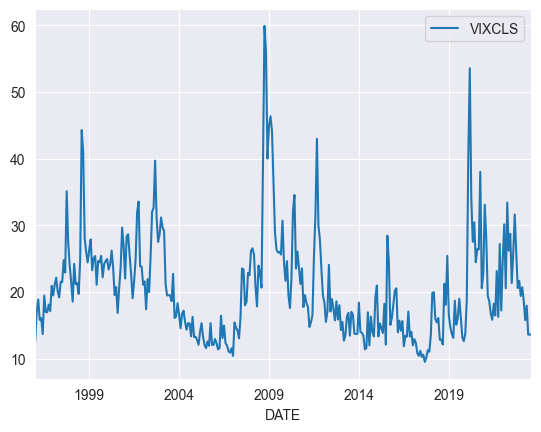

In [ ]:
vix.plot(figsize=(12, 4), title='VIX'); plt.show()

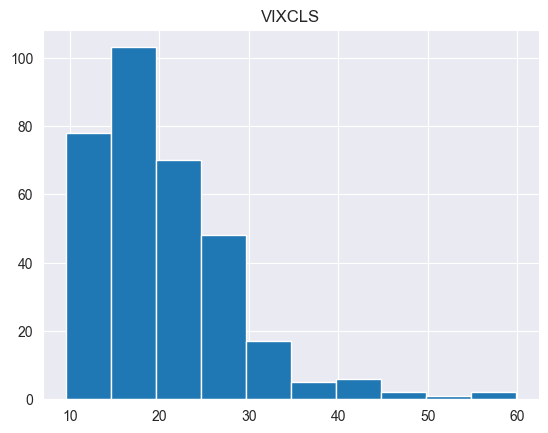

In [ ]:
vix.hist(bins=40); plt.title('Distribution of VIX'); plt.show()

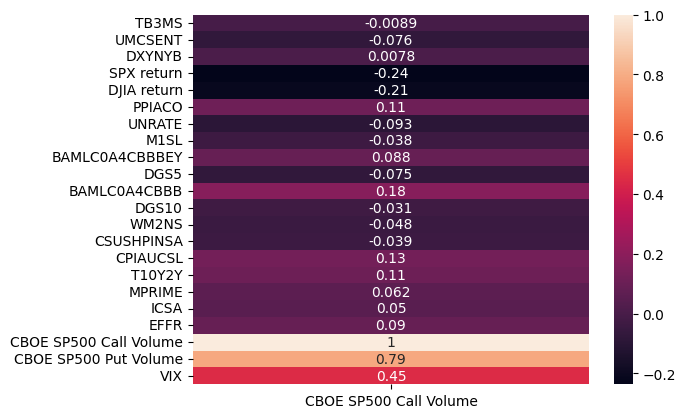

In [ ]:
combined = exog.join(vix).dropna()
corr = combined.corr()
plt.figure(figsize=(4, 8))
sns.heatmap(corr[[vix.columns[0]]], annot=True, cmap='vlag', center=0)
plt.title('Correlation of regressors with VIX'); plt.tight_layout(); plt.show()

## 4. Stationarity and autocorrelation

ACF/PACF characterise the VIX's autocorrelation structure, and an Augmented
Dickey–Fuller test checks stationarity (the order of integration that
`auto_arima` should consider).


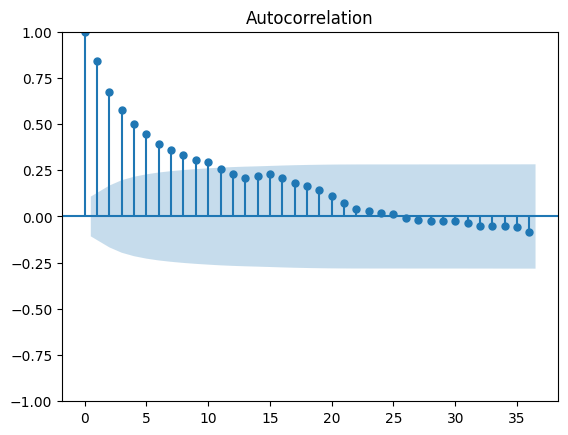

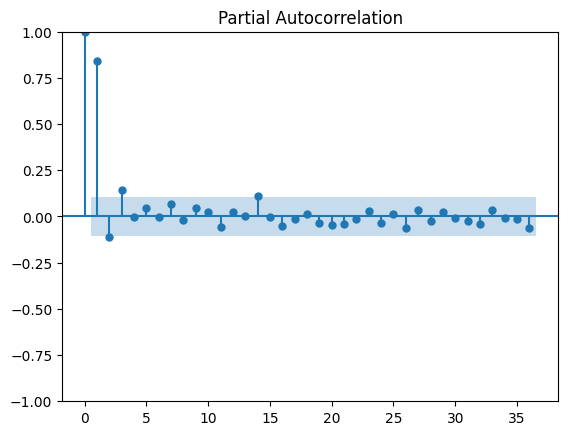

In [ ]:
vix_data = vix.iloc[:, 0].dropna()
plot_acf(vix_data, lags=36); plt.show()
plot_pacf(vix_data, lags=36); plt.show()

In [ ]:
result = adfuller(vix_data)
print('Augmented Dickey-Fuller test')
print(f'Test statistic: {result[0]:.4f}')
print(f'p-value:        {result[1]:.6f}')
print(f'Lags used:      {result[2]}')
print(f'N observations: {result[3]}')
print('Critical values:')
for k, v in result[4].items():
    print(f'  {k}: {v:.4f}')
print('Stationary (reject unit root).' if result[1] <= 0.05
      else 'Non-stationary; differencing needed.')

Dickey-Fuller Test Results:
Test Statistic: -4.670414879930406
p-value: 9.560742156141317e-05
Number of Lags Used: 2
Number of Observations Used: 329
Critical Values:
1%: -3.4503836022181056
5%: -2.8703653471616826
10%: -2.571471939191249
Result: Reject the null hypothesis. Data is stationary and no differencing is needed


## 5. Chronological split and evaluation helpers

The split is strictly time-ordered: the first 80% of observations train, the
last 20% test. **Mean directional accuracy (MDA)** measures how often the
forecast gets the sign of the next change right — the key property for a
volatility signal.


In [ ]:
def chrono_split(X, y, train_frac=0.8):
    """Time-ordered split (no shuffling); keeps X and y aligned."""
    n = len(y)
    k = int(n * train_frac)
    return X.iloc[:k], X.iloc[k:], y.iloc[:k], y.iloc[k:]


def mda(actual, predicted):
    """Mean directional accuracy: share of correctly predicted up/down moves."""
    actual = np.asarray(actual).ravel()
    predicted = np.asarray(predicted).ravel()
    return float(np.mean(np.sign(np.diff(actual)) == np.sign(np.diff(predicted))))

## 6. Model 1 — SARIMAX with exogenous regressors

`auto_arima` selects the (p, d, q)(P, D, Q) order by AIC, with the macro/credit
variables entered as exogenous regressors. The fitted model produces a
point forecast with confidence intervals over the test window, plus standard
residual diagnostics.


In [ ]:
def fit_sarimax(X, y, seasonal=True, m=12):
    x_train, x_test, y_train, y_test = chrono_split(X, y)

    model = pm.auto_arima(
        y=y_train, X=x_train,
        start_p=1, start_q=1, max_p=9, max_d=2, max_q=9,
        m=m, seasonal=seasonal, start_P=0,
        stepwise=True, suppress_warnings=True,
        out_of_sample_size=20, error_action='ignore', trace=False)
    print(model.summary())

    pred, ci = model.predict(n_periods=len(y_test), return_conf_int=True, X=x_test)
    ci = pd.DataFrame(ci, index=y_test.index)
    pred = pd.Series(pred, index=y_test.index)

    print(f"\nTest MSE: {mean_squared_error(y_test, pred):.3f}")
    print(f"Test MDA: {mda(y_test, pred):.3f}")

    fig, ax = plt.subplots(figsize=(15, 5))
    ax.plot(y, label='actual')
    ax.plot(pred, label='forecast')
    ax.fill_between(pred.index, ci[0], ci[1], color='grey', alpha=.3)
    ax.legend(); plt.show()

    model.plot_diagnostics(figsize=(14, 10)); plt.show()
    return model

**All regressors.** Using the full exogenous set as a first pass:

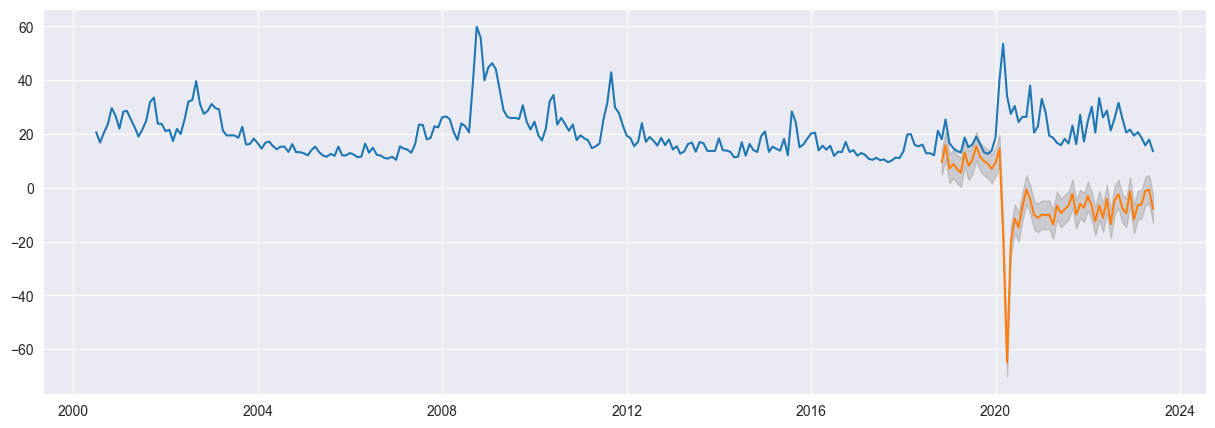

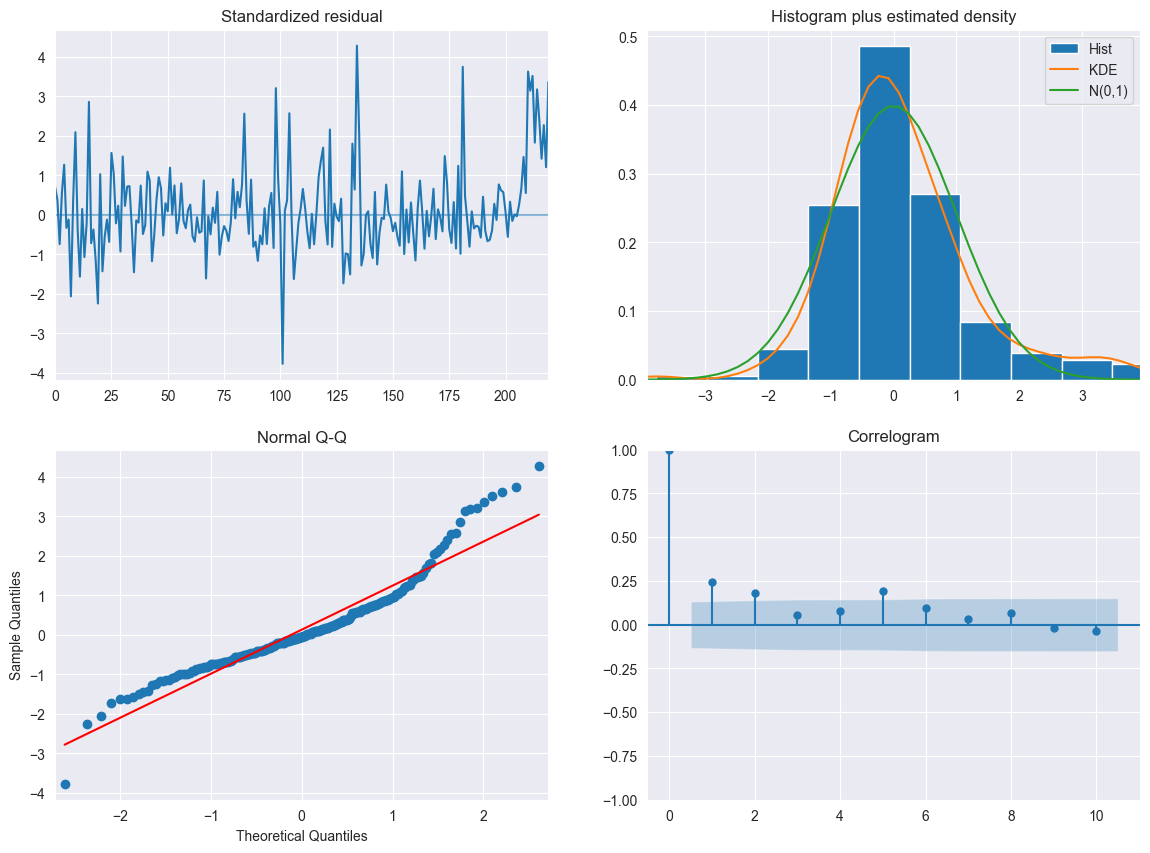

In [ ]:
sarimax_full = fit_sarimax(exog[54:330], vix[54:330])

**Selected regressors.** Restricting to the most informative and least
collinear regressors (credit spreads, equity returns, sentiment, unemployment)
to reduce overfitting and multicollinearity:

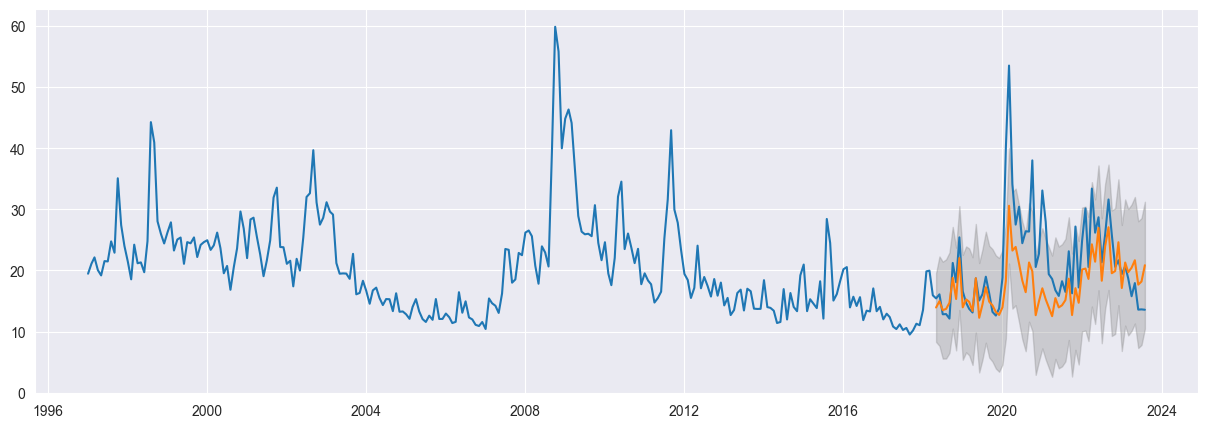

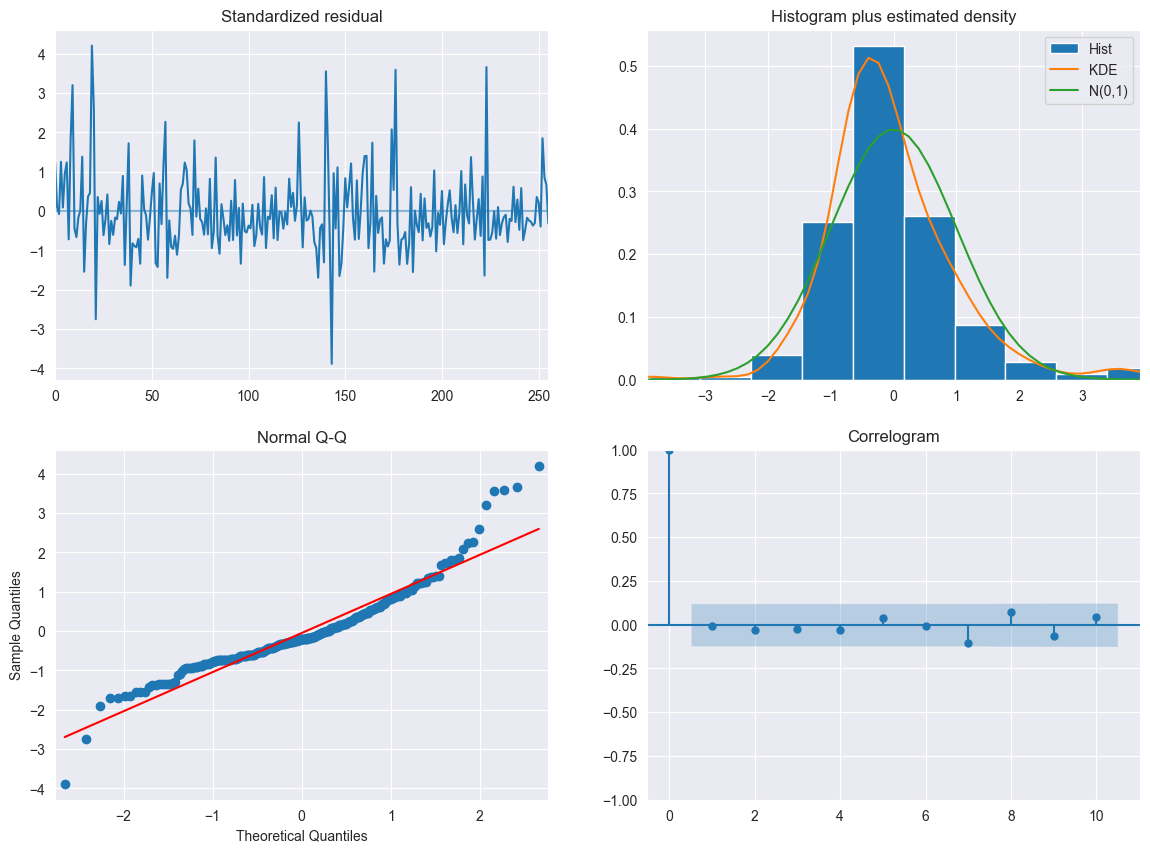

In [ ]:
selected_features = exog[['BAMLC0A4CBBB', 'BAMLC0A4CBBBEY', 'SPX return',
                          'DJIA return', 'UMCSENT', 'UNRATE']]
sarimax_sel = fit_sarimax(selected_features[12:], vix[12:])

## 7. Model 2 — SARIMAX mean + GARCH(2,1) variance

The VIX exhibits volatility clustering, so a constant-variance SARIMAX
understates uncertainty in turbulent periods. A two-stage approach addresses
this: SARIMAX models the conditional *mean*, and a GARCH(2,1) process is fit to
the SARIMAX residuals to model the conditional *variance*. The point forecast
comes from SARIMAX; GARCH supplies a time-varying volatility (interval) forecast.


In [ ]:
def fit_sarimax_garch(X, y):
    x_train, x_test, y_train, y_test = chrono_split(X, y)

    # stage 1: SARIMAX for the conditional mean
    arima_model = pm.auto_arima(
        y=y_train, X=x_train,
        start_p=1, start_q=1, max_p=9, max_d=2, max_q=9,
        seasonal=False, stepwise=True, suppress_warnings=True,
        out_of_sample_size=10, error_action='ignore', trace=False)

    # stage 2: GARCH(2,1) on the SARIMAX residuals (scaled for numerical stability)
    resid = pd.Series(arima_model.resid()).dropna()
    garch = arch_model(resid, mean='Zero', vol='GARCH', p=2, q=1)
    garch_res = garch.fit(disp='off')
    print(garch_res.summary())

    # mean forecast from SARIMAX; volatility forecast from GARCH
    mu, ci = arima_model.predict(n_periods=len(y_test), return_conf_int=True, X=x_test)
    mu = pd.Series(mu, index=y_test.index)
    sigma = np.sqrt(garch_res.forecast(horizon=len(y_test)).variance.values[-1])

    print(f"\nTest MSE: {mean_squared_error(y_test, mu):.3f}")
    print(f"Test MDA: {mda(y_test, mu):.3f}")

    fig, ax = plt.subplots(figsize=(15, 5))
    ax.plot(y, label='actual')
    ax.plot(mu, label='SARIMAX mean forecast')
    ax.fill_between(mu.index, mu - 1.96 * sigma, mu + 1.96 * sigma,
                    color='orange', alpha=.25, label='GARCH 95% band')
    ax.legend(); plt.show()
    return arima_model, garch_res

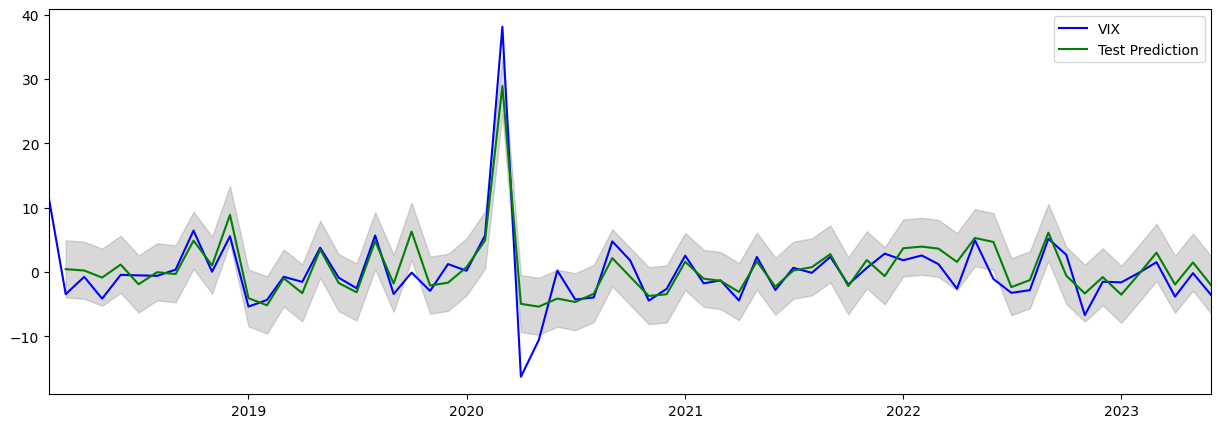

In [ ]:
garch_features = exog[['BAMLC0A4CBBB', 'SPX return', 'UMCSENT',
                       'DGS10', 'CBOE SP500 Put Volume']]
arima_m, garch_m = fit_sarimax_garch(garch_features[13:], vix[13:])

## 8. Findings and limitations

**Approach.** The VIX is forecast from macro/credit fundamentals rather than its
own history alone. Credit spreads (`BAMLC0A4CBBB`) and equity returns carry the
most signal, consistent with the VIX being a risk-premium gauge. SARIMAX handles
the conditional mean; the GARCH layer captures volatility clustering for
honest interval forecasts. Directional accuracy (MDA) is reported alongside MSE
because, for a volatility signal, the sign of the next move is the actionable
output.

**Methodological corrections vs. the original.** (1) The train/test split is now
strictly chronological — the previous `train_test_split` shuffled the series and
mis-aligned X and y, invalidating the evaluation. (2) The GARCH stage uses a
zero-mean spec on the SARIMAX residuals (the correct object to model), rather
than passing exogenous regressors into `arch_model` where they have no defined
role.

**Limitations / next steps.**
- Single hold-out; a **rolling/walk-forward** evaluation (re-fit at each step)
  would give a far more reliable estimate of live performance and is the natural
  next iteration.
- `auto_arima` minimises in-sample AIC; pairing it with the walk-forward loop
  guards against order-selection overfitting.
- Exogenous regressors are treated as contemporaneously available; for genuine
  forecasting they must be **lagged** so only information available at forecast
  time is used. Worth auditing each regressor for look-ahead.
- No transaction-cost or trading-rule layer — MDA is a statistical, not an
  economic, measure of value.
